# PRAKTIKUM 4 - UNSUPERVISED LEARNING : K-MEANS
## Klasterisasi Tingkat Kerentanan Sosial-Ekonomi Kabupaten/Kota di Indonesia

**Sumber data:** Badan Pusat Statistik (BPS) - komponen IPM Metode Baru per kabupaten/kota  
(Umur Harapan Hidup 2024; Harapan Lama Sekolah, Rata-rata Lama Sekolah, Pengeluaran per Kapita 2025)

### Proses Klustering Menggunakan Algoritma K-Means

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Memuat file Excel
jalur_file = 'Kesejahteraan_Daerah.xlsx'
df = pd.read_excel(jalur_file)

# Memilih kolom numerik yang relevan untuk klustering
kolom_numerik = [
    'Umur Harapan Hidup (Tahun)',
    'Harapan Lama Sekolah (Tahun)',
    'Rata-rata Lama Sekolah (Tahun)',
    'Pengeluaran per Kapita (Ribu Rupiah)'
]

# Praproses data dengan menstandarkan
skaler = StandardScaler()
data_distandarkan = skaler.fit_transform(df[kolom_numerik])

# Menerapkan K-Means klustering dengan 3 kluster
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(data_distandarkan)
df['kluster'] = kmeans.labels_

# Mengurutkan nomor kluster berdasarkan tingkat kesejahteraan
# (skor terendah -> 0 = Rentan, sedang -> 1 = Berkembang, tertinggi -> 2 = Sejahtera)
skor = data_distandarkan.mean(axis=1)
urutan = pd.Series(skor).groupby(df['kluster']).mean().sort_values().index
peta_urut = {lama: baru for baru, lama in enumerate(urutan)}
df['kluster'] = df['kluster'].map(peta_urut)


### Menampilkan Hasil Klustering K-Means

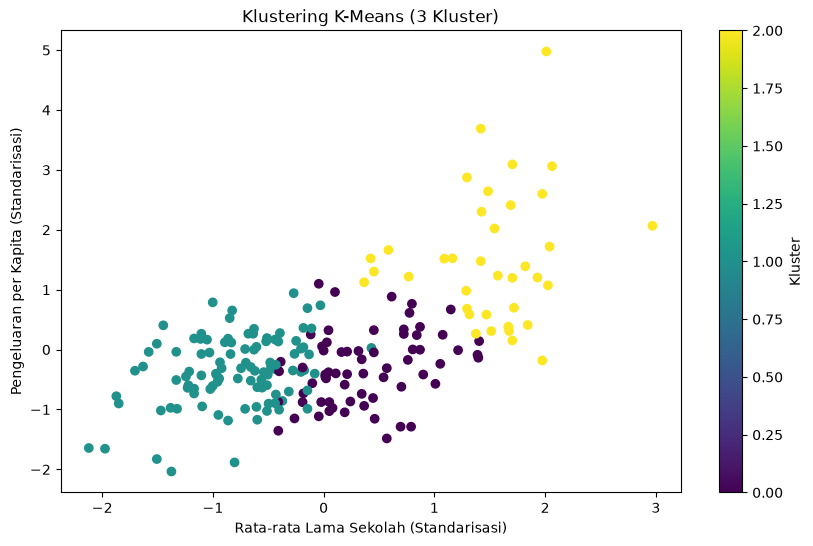

  Provinsi Kabupaten/Kota  Umur Harapan Hidup (Tahun)  \
0     Aceh       Simeulue                       65.73   
1     Aceh   Aceh Singkil                       67.89   
2     Aceh   Aceh Selatan                       64.97   
3     Aceh  Aceh Tenggara                       68.78   
4     Aceh     Aceh Timur                       69.18   

   Harapan Lama Sekolah (Tahun)  Rata-rata Lama Sekolah (Tahun)  \
0                         14.59                           10.09   
1                         14.37                            9.05   
2                         14.72                            9.25   
3                         14.52                           10.39   
4                         13.09                            8.80   

   Pengeluaran per Kapita (Ribu Rupiah)  kluster  
0                                  8555        0  
1                                 10227        0  
2                                  9573        0  
3                                  9097        0  

In [2]:
# Plot Kluster
plt.figure(figsize=(10, 6))
plt.scatter(
    data_distandarkan[:, 2],
    data_distandarkan[:, 3],
    c=df['kluster'],
    cmap='viridis'
)
plt.xlabel('Rata-rata Lama Sekolah (Standarisasi)')
plt.ylabel('Pengeluaran per Kapita (Standarisasi)')
plt.title('Klustering K-Means (3 Kluster)')
plt.colorbar(label='Kluster')
plt.show()

# Menyimpan dataframe dengan label kluster
df.to_excel('Kesejahteraan_kluster.xlsx', index=False)

# Menampilkan beberapa baris pertama
print(df.head())

### Membaca Dataset Hasil Klustering

In [3]:
df = pd.read_excel('Kesejahteraan_kluster.xlsx')
df

,Provinsi,Kabupaten/Kota,Umur Harapan Hidup (Tahun),Harapan Lama Sekolah (Tahun),Rata-rata Lama Sekolah (Tahun),Pengeluaran per Kapita (Ribu Rupiah),kluster
0,Aceh,Simeulue,65.73,14.59,10.09,8555,0
1,Aceh,Aceh Singkil,67.89,14.37,9.05,10227,0
2,Aceh,Aceh Selatan,64.97,14.72,9.25,9573,0
3,Aceh,Aceh Tenggara,68.78,14.52,10.39,9097,0
4,Aceh,Aceh Timur,69.18,13.09,8.80,10284,1
...,...,...,...,...,...,...,...
200,Kalimantan Selatan,Tabalong,71.46,13.18,9.37,13541,0
201,Kalimantan Selatan,Tanah Bumbu,71.11,12.80,8.44,13380,1
202,Kalimantan Selatan,Balangan,68.59,13.35,8.34,12675,1
203,Kalimantan Selatan,Kota Banjarmasin,72.10,14.02,10.36,16013,2


### Menentukan Data Latih (X) dan Label (Y)

In [4]:
# Kolom 0 = Provinsi, 1 = Kabupaten/Kota, 2..5 = fitur numerik, 6 = kluster
x = df.iloc[:, 2:6]
y = df.iloc[:, 6]

### Membagi Data dan Melatih Model Naive Bayes

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Split data menjadi data training dan data testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Pisahkan salah satu kolom untuk tujuan validasi
rls_train, rls_test = train_test_split(
    df['Rata-rata Lama Sekolah (Tahun)'],
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Terapkan SMOTE untuk oversampling kelas minoritas
smote = SMOTE(random_state=42, k_neighbors=3)
x_train, y_train = smote.fit_resample(x_train, y_train)

# Normalisasi data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Buat model Naive Bayes
model = GaussianNB()

# Latih model dengan data training
model.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[81.,81.,81.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 4)","[[-0.36, 0.06, 0.02,-0.52], [-0.61,-0.94,-1.12,-0.52], [ 0.98, 0.88, 1.09, 1.04]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 4)","[[0.63,0.29,0.16,0.3 ], [0.62,0.2 ,0.2 ,0.32], [0.29,0.84,0.19,0.78]]"


### Menguji dan Melihat Hasil Prediksi Naive Bayes

In [6]:
from sklearn.metrics import accuracy_score, classification_report

# Prediksi label untuk data testing
y_pred = model.predict(x_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

# Tampilkan hasil evaluasi
print('Accuracy :', accuracy)
print('Classification Report:\n')
print(report)

Accuracy : 0.975609756097561
Classification Report:

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00         7

    accuracy                           0.98        41
   macro avg       0.98      0.98      0.98        41
weighted avg       0.98      0.98      0.98        41



### Menyimpan Hasil Prediksi Naive Bayes

In [7]:
# Dictionary untuk pemetaan label numerik ke label teks
label_map = {0: 'Rentan', 1: 'Berkembang', 2: 'Sejahtera'}

# Membuat DataFrame hasil prediksi
hasil_prediksi = pd.DataFrame({
    'Rata-rata Lama Sekolah (Tahun)': rls_test.reset_index(drop=True),
    'Label Asli': y_test.reset_index(drop=True),
    'Prediksi': pd.Series(y_pred)
})

# Mengubah label angka menjadi teks
hasil_prediksi['Label Asli'] = hasil_prediksi['Label Asli'].map(label_map)
hasil_prediksi['Prediksi'] = hasil_prediksi['Prediksi'].map(label_map)

# Simpan ke Excel
hasil_prediksi.to_excel('Hasil Prediksi Naive Bayes.xlsx', index=False)
print('Hasil prediksi telah diekspor ke file Hasil Prediksi Naive Bayes.xlsx')
hasil_prediksi.head()

Hasil prediksi telah diekspor ke file Hasil Prediksi Naive Bayes.xlsx


,Rata-rata Lama Sekolah (Tahun),Label Asli,Prediksi
0,8.75,Rentan,Rentan
1,8.93,Berkembang,Berkembang
2,7.30,Berkembang,Berkembang
3,8.45,Berkembang,Berkembang
4,10.40,Rentan,Rentan


### Klasifikasi Menggunakan Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Buat model Random Forest
model = RandomForestClassifier(random_state=42)

# Latih model menggunakan data pelatihan yang telah di-resample
model.fit(x_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(x_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=1)

# Cetak hasil
print('Accuracy :', accuracy)
print('Classification Report:\n')
print(report)

# Simpan hasil prediksi Random Forest
hasil_rf = pd.DataFrame({
    'Rata-rata Lama Sekolah (Tahun)': rls_test.reset_index(drop=True),
    'Label Asli': y_test.reset_index(drop=True),
    'Prediksi': pd.Series(y_pred)
})
hasil_rf['Label Asli'] = hasil_rf['Label Asli'].map(label_map)
hasil_rf['Prediksi'] = hasil_rf['Prediksi'].map(label_map)
hasil_rf.to_excel('Hasil Prediksi Random Forest.xlsx', index=False)
print("Hasil prediksi berhasil disimpan ke file 'Hasil Prediksi Random Forest.xlsx'")

Accuracy : 0.926829268292683
Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        13
           1       0.95      0.90      0.93        21
           2       1.00      1.00      1.00         7

    accuracy                           0.93        41
   macro avg       0.94      0.94      0.94        41
weighted avg       0.93      0.93      0.93        41

Hasil prediksi berhasil disimpan ke file 'Hasil Prediksi Random Forest.xlsx'


### Klasifikasi Menggunakan Support Vector Machine (SVM)

In [9]:
from sklearn.svm import SVC

# Inisialisasi model SVM dengan kernel RBF
model = SVC(kernel='rbf', random_state=42)

# Latih model menggunakan data pelatihan
model.fit(x_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(x_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=1)

# Cetak hasil
print('Accuracy:', accuracy)
print('Classification Report:\n', report)

# Simpan hasil prediksi SVM
hasil_svm = pd.DataFrame({
    'Rata-rata Lama Sekolah (Tahun)': rls_test.reset_index(drop=True),
    'Label Asli': y_test.reset_index(drop=True),
    'Prediksi': pd.Series(y_pred)
})
hasil_svm['Label Asli'] = hasil_svm['Label Asli'].map(label_map)
hasil_svm['Prediksi'] = hasil_svm['Prediksi'].map(label_map)
hasil_svm.to_excel('Hasil Prediksi SVM.xlsx', index=False)
print("Hasil prediksi berhasil disimpan ke file 'Hasil Prediksi SVM.xlsx'")

Accuracy: 0.975609756097561
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00         7

    accuracy                           0.98        41
   macro avg       0.98      0.98      0.98        41
weighted avg       0.98      0.98      0.98        41

Hasil prediksi berhasil disimpan ke file 'Hasil Prediksi SVM.xlsx'
